In [206]:
import pandas as pd
pd.set_option("display.max_columns", None)
import numpy as np
import matplotlib.pyplot as plt
import re

In [207]:
df = pd.read_csv('patient2.csv', encoding="utf-8")
df.head()

,Birthdate,ID,Gender,Age,Birth Order,Mother's Age at Pregnancy (Years),Abortion History,Type of Delivery,Mother Underweight (BMI < 18.5),Pressure,Blood Pressure (Week 24-30) - Systolic,Blood Pressure (Week 24-30) - Diastolic,Blood Pressure (Week 31-34) - Systolic,Blood Pressure (Week 31-34) - Diastolic,Blood Pressure (Week 36-37) - Systolic,Blood Pressure (Week 36-37) - Diastolic,Pregnancy Weeks,Gestational Diabetes,Diabetes (Week 6-10),Diabetes (Week 24-30),Developmental Issues (2 Months),Developmental Issues (9 Months),Developmental Issues (18 Months),Breast Milk Sufficiency (3-5 Days),Head Circumference at Birth (cm),Head Circumference (14-15 Days),Head Circumference at 1 Year (cm),Head Circumference Check (14-15 Days),Head Circumference Check (1 Year),Height at Birth (cm),Height at 6 Months (cm),Height at 12 Months (cm),Height at 18 Months (cm),Height at 2 Years (cm),Height at 3 Years (cm),Height at 4 Years (cm),Weight at Birth (kg),Weight at 6 Months (kg),Weight at 12 Months (kg),Weight at 18 Months (kg),Weight at 2 Years (kg),Weight at 3 Years (kg),Weight at 4 Years (kg),Hypothyroidism (3-5 Days),Malnutrition Type
0,1400/11/20,2501037121,1,39,1,35,NaN,2,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1,83.0,105.0,2,3,2,3,NaN,NaN,43.5,NaN,1.0,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,7.50,NaN,NaN,NaN,NaN,3,4
1,1399/10/04,2501014456,1,52,3,37,2.0,2,2.0,90.0,50.0,100.0,50.0,90.0,50.0,39.0,2.0,1,82.0,92.0,2,2,2,2,34.5,35.0,44.5,1.0,1.0,52.0,63.0,69.0,74.0,80.0,86.0,89.0,2.885,6.67,7.65,7.75,8.65,9.6,10.5,2,"2 , 4 , 6"
2,1401/02/20,2501041682,1,36,2,30,1.0,2,2.0,NaN,NaN,130.0,70.0,NaN,NaN,36.0,1.0,2,86.0,70.0,2,2,2,1,34.0,34.0,45.0,1.0,1.0,48.0,NaN,72.0,74.5,NaN,NaN,NaN,2.700,NaN,7.10,7.40,NaN,NaN,NaN,3,"2 ,4 , 6"
3,1401/09/22,5150479861,2,29,1,29,2.0,2,2.0,100.0,60.0,102.0,60.0,105.0,65.0,40.0,2.0,3,NaN,NaN,2,3,2,1,35.0,37.0,46.5,1.0,1.0,50.0,68.0,72.0,78.0,NaN,NaN,NaN,3.260,7.19,8.00,9.00,NaN,NaN,NaN,1,"4 , 6"
4,1400/03/02,2501021185,2,48,2,32,2.0,2,2.0,110.0,70.0,115.0,70.0,NaN,NaN,39.0,2.0,2,NaN,79.0,2,2,2,2,31.0,NaN,43.0,NaN,1.0,50.0,65.0,72.0,76.0,80.0,86.0,NaN,2.700,7.10,8.20,9.10,9.45,12.0,NaN,3,"4 , 6"


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 45 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Birthdate                                30 non-null     object 
 1   ID                                       30 non-null     int64  
 2   Gender                                   30 non-null     int64  
 3   Age                                      30 non-null     int64  
 4   Birth Order                              30 non-null     int64  
 5   Mother's Age at Pregnancy (Years)        30 non-null     int64  
 6   Abortion History                         22 non-null     float64
 7   Type of Delivery                         30 non-null     int64  
 8   Mother Underweight (BMI < 18.5)          29 non-null     float64
 9   Pressure                                 24 non-null     float64
 10  Blood Pressure (Week 24-30) - Systolic   24 non-null

In [209]:
# حذف مقادر یونیک
df.drop(columns=["Birthdate","ID"], inplace=True)

In [210]:
df["Birth Order"].unique()

array([1, 3, 2, 4], dtype=int64)

In [211]:
#تبدیل مقادیر چندمین فرزند به عدد
df["Birth Order"].replace("3-3قلو","33", inplace=True)
df["Birth Order"].replace("دوقلو","22", inplace=True)
df["Birth Order"].replace("چهارقلو","44", inplace=True)
df["Birth Order"].replace("nan",np.nan,inplace=True)
df["Birth Order"] = pd.to_numeric(df["Birth Order"], errors='coerce').astype('Int64')
df["Birth Order"].unique()

<IntegerArray>
[1, 3, 2, 4]
Length: 4, dtype: Int64

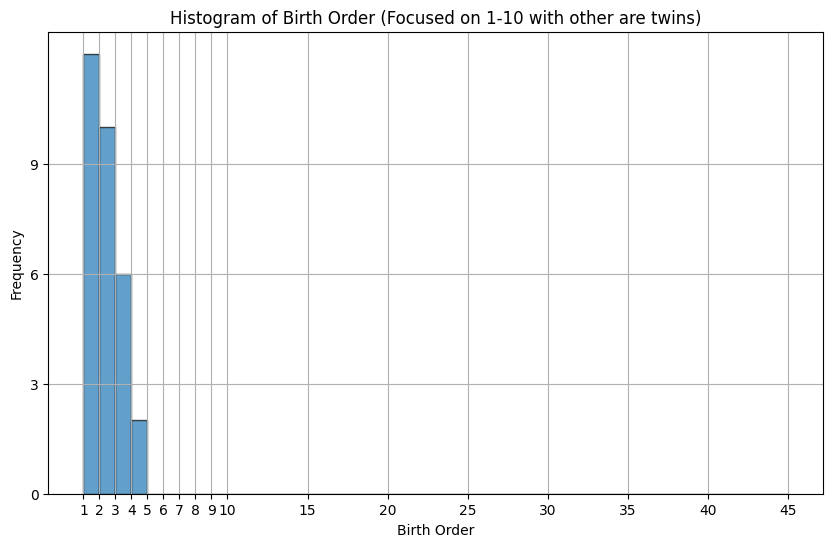

In [212]:
# نمایش هستوگرام چندمین فرزند
bins = list(range(1, 11)) + [15, 20, 25, 30, 35, 40, 45]


plt.figure(figsize=(10, 6))
df["Birth Order"].hist(bins=bins, edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on 1-10 with other are twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(bins)
max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()


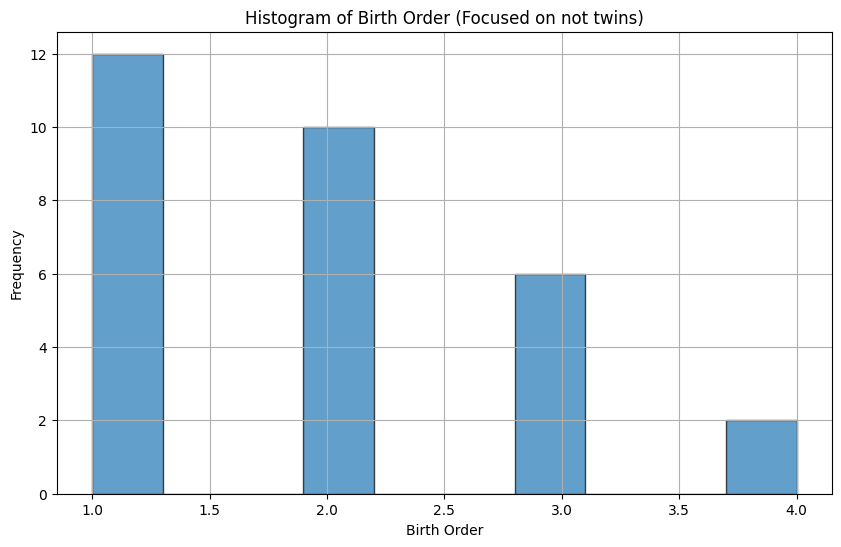

In [213]:
#هستوگرام بدون در نظر گرفتن چند قلو ها
plt.figure(figsize=(10, 6))
df["Birth Order"].where(df["Birth Order"]<10).hist(edgecolor='black', alpha=0.7)

# Highlight the common range with a different background color
# plt.axvspan(1, 10, color='yellow', alpha=0.1)

plt.xlabel("Birth Order")
plt.ylabel("Frequency")
plt.title("Histogram of Birth Order (Focused on not twins)")
# plt.grid(axis='y', linestyle='--', alpha=0.7)
# max_y_value = plt.gca().get_ylim()[1]  # Get the max y value from the plot
# plt.yticks(range(0, int(max_y_value), 3))  # Adjust the step size here
plt.show()


In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   30 non-null     int64  
 1   Age                                      30 non-null     int64  
 2   Birth Order                              30 non-null     Int64  
 3   Mother's Age at Pregnancy (Years)        30 non-null     int64  
 4   Abortion History                         22 non-null     float64
 5   Type of Delivery                         30 non-null     int64  
 6   Mother Underweight (BMI < 18.5)          29 non-null     float64
 7   Pressure                                 24 non-null     float64
 8   Blood Pressure (Week 24-30) - Systolic   24 non-null     float64
 9   Blood Pressure (Week 24-30) - Diastolic  24 non-null     float64
 10  Blood Pressure (Week 31-34) - Systolic   24 non-null

In [215]:
df["Head Circumference at Birth (cm)"].unique()

array([ nan, 34.5, 34. , 35. , 31. , 32. , 33. , 29.5])

In [216]:
df["Head Circumference at Birth (cm)"] = pd.to_numeric(df["Head Circumference at Birth (cm)"], errors='coerce').astype('float64')

In [217]:
df["Head Circumference at Birth (cm)"].unique()

array([ nan, 34.5, 34. , 35. , 31. , 32. , 33. , 29.5])

In [218]:
df["Weight at Birth (kg)"].unique()

array([      nan, 2.885e+00, 2.700e+00, 3.260e+00, 2.900e+00, 2.500e+00,
       2.570e+00, 2.970e+00, 3.345e+00, 2.600e+03, 3.000e+03, 3.250e+03,
       1.790e+03, 2.785e+03, 3.070e+03, 1.670e+03, 2.590e+03, 2.800e+03,
       3.145e+03, 2.400e+03, 2.840e+03, 2.700e+03])

In [219]:
df["Weight at Birth (kg)"] = pd.to_numeric(df["Weight at Birth (kg)"], errors='coerce').astype('float64')

In [220]:
df["Weight at Birth (kg)"].unique()

array([      nan, 2.885e+00, 2.700e+00, 3.260e+00, 2.900e+00, 2.500e+00,
       2.570e+00, 2.970e+00, 3.345e+00, 2.600e+03, 3.000e+03, 3.250e+03,
       1.790e+03, 2.785e+03, 3.070e+03, 1.670e+03, 2.590e+03, 2.800e+03,
       3.145e+03, 2.400e+03, 2.840e+03, 2.700e+03])

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   30 non-null     int64  
 1   Age                                      30 non-null     int64  
 2   Birth Order                              30 non-null     Int64  
 3   Mother's Age at Pregnancy (Years)        30 non-null     int64  
 4   Abortion History                         22 non-null     float64
 5   Type of Delivery                         30 non-null     int64  
 6   Mother Underweight (BMI < 18.5)          29 non-null     float64
 7   Pressure                                 24 non-null     float64
 8   Blood Pressure (Week 24-30) - Systolic   24 non-null     float64
 9   Blood Pressure (Week 24-30) - Diastolic  24 non-null     float64
 10  Blood Pressure (Week 31-34) - Systolic   24 non-null

In [222]:
df["Gender"].unique()

array([1, 2], dtype=int64)

In [223]:
df["Gender"] = pd.to_numeric(df["Gender"], errors='coerce').astype('Int64')
df["Gender"].unique()

<IntegerArray>
[1, 2]
Length: 2, dtype: Int64

In [224]:
df["Age"] = pd.to_numeric(df["Age"], errors='coerce').astype('Int64')

In [225]:
df["Pressure"].unique()

array([ nan,  90., 100., 110.,  95., 120.,  50.,  60.,  67.,  70.,  54.,
        80.])

In [226]:
df["Pressure"] = pd.to_numeric(df["Pressure"], errors='coerce').astype('Int64')
df["Pressure"].unique()

<IntegerArray>
[<NA>, 90, 100, 110, 95, 120, 50, 60, 67, 70, 54, 80]
Length: 12, dtype: Int64

In [227]:
df["Abortion History"] = pd.to_numeric(df["Abortion History"], errors='coerce').astype('Int64')

In [228]:
df["Mother's Age at Pregnancy (Years)"] = pd.to_numeric(df["Mother's Age at Pregnancy (Years)"], errors='coerce').astype('Int64')

In [229]:
df["Type of Delivery"] = pd.to_numeric(df["Type of Delivery"], errors='coerce').astype('Int64')

In [230]:
df["Mother Underweight (BMI < 18.5)"] = pd.to_numeric(df["Mother Underweight (BMI < 18.5)"], errors='coerce').astype('Int64')

In [231]:
df["Blood Pressure (Week 24-30) - Systolic"] = pd.to_numeric(df["Blood Pressure (Week 24-30) - Systolic"], errors='coerce').astype('Int64')
df["Blood Pressure (Week 24-30) - Diastolic"] = pd.to_numeric(df["Blood Pressure (Week 24-30) - Systolic"], errors='coerce').astype('Int64')

In [232]:
df["Blood Pressure (Week 31-34) - Systolic"] = pd.to_numeric(df["Blood Pressure (Week 31-34) - Systolic"], errors='coerce').astype('Int64')
df["Blood Pressure (Week 31-34) - Diastolic"] = pd.to_numeric(df["Blood Pressure (Week 31-34) - Systolic"], errors='coerce').astype('Int64')

In [233]:
df["Blood Pressure (Week 36-37) - Systolic"] = pd.to_numeric(df["Blood Pressure (Week 36-37) - Systolic"], errors='coerce').astype('Int64')
df["Blood Pressure (Week 36-37) - Diastolic"] = pd.to_numeric(df["Blood Pressure (Week 36-37) - Systolic"], errors='coerce').astype('Int64')

In [234]:
df["Pregnancy Weeks"] = pd.to_numeric(df["Pregnancy Weeks"], errors='coerce').astype('Int64')

In [235]:
df["Gestational Diabetes"] = pd.to_numeric(df["Gestational Diabetes"], errors='coerce').astype('Int64')

In [236]:
df["Diabetes (Week 6-10)"] = pd.to_numeric(df["Diabetes (Week 6-10)"], errors='coerce').astype('Int64')

In [237]:
df["Developmental Issues (2 Months)"] = pd.to_numeric(df["Developmental Issues (2 Months)"], errors='coerce').astype('Int64')
df["Developmental Issues (9 Months)"] = pd.to_numeric(df["Developmental Issues (9 Months)"], errors='coerce').astype('Int64')
df["Developmental Issues (18 Months)"] = pd.to_numeric(df["Developmental Issues (18 Months)"], errors='coerce').astype('Int64')

In [238]:
df["Breast Milk Sufficiency (3-5 Days)"] = pd.to_numeric(df["Breast Milk Sufficiency (3-5 Days)"], errors='coerce').astype('Int64')

In [239]:
df["Malnutrition Type"].unique()

array(['4', '2 , 4 , 6', '2 ,4 , 6', '4 , 6', '2 , 4', '2', '1', '1,3,6',
       '4,5', '2,3,6', '2,4,6', '3,5', '6', '4,6', '2,3,5', '2,4'],
      dtype=object)

In [240]:
df["Malnutrition Type"] = df["Malnutrition Type"].apply(lambda x: [s.strip() for s in re.split('[,و]', str(x))] if pd.notna(x) else [])

In [241]:
df.head()

,Gender,Age,Birth Order,Mother's Age at Pregnancy (Years),Abortion History,Type of Delivery,Mother Underweight (BMI < 18.5),Pressure,Blood Pressure (Week 24-30) - Systolic,Blood Pressure (Week 24-30) - Diastolic,Blood Pressure (Week 31-34) - Systolic,Blood Pressure (Week 31-34) - Diastolic,Blood Pressure (Week 36-37) - Systolic,Blood Pressure (Week 36-37) - Diastolic,Pregnancy Weeks,Gestational Diabetes,Diabetes (Week 6-10),Diabetes (Week 24-30),Developmental Issues (2 Months),Developmental Issues (9 Months),Developmental Issues (18 Months),Breast Milk Sufficiency (3-5 Days),Head Circumference at Birth (cm),Head Circumference (14-15 Days),Head Circumference at 1 Year (cm),Head Circumference Check (14-15 Days),Head Circumference Check (1 Year),Height at Birth (cm),Height at 6 Months (cm),Height at 12 Months (cm),Height at 18 Months (cm),Height at 2 Years (cm),Height at 3 Years (cm),Height at 4 Years (cm),Weight at Birth (kg),Weight at 6 Months (kg),Weight at 12 Months (kg),Weight at 18 Months (kg),Weight at 2 Years (kg),Weight at 3 Years (kg),Weight at 4 Years (kg),Hypothyroidism (3-5 Days),Malnutrition Type
0,1,39,1,35,<NA>,2,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,1,83,105.0,2,3,2,3,NaN,NaN,43.5,NaN,1.0,NaN,NaN,70.0,NaN,NaN,NaN,NaN,NaN,NaN,7.50,NaN,NaN,NaN,NaN,3,[4]
1,1,52,3,37,2,2,2,90,50,50,50,50,50,50,2,1,82,92.0,2,2,2,2,34.5,35.0,44.5,1.0,1.0,52.0,63.0,69.0,74.0,80.0,86.0,89.0,2.885,6.67,7.65,7.75,8.65,9.6,10.5,2,"[2, 4, 6]"
2,1,36,2,30,1,2,2,<NA>,<NA>,<NA>,70,70,<NA>,<NA>,1,2,86,70.0,2,2,2,1,34.0,34.0,45.0,1.0,1.0,48.0,NaN,72.0,74.5,NaN,NaN,NaN,2.700,NaN,7.10,7.40,NaN,NaN,NaN,3,"[2, 4, 6]"
3,2,29,1,29,2,2,2,100,60,60,60,60,65,65,2,3,<NA>,NaN,2,3,2,1,35.0,37.0,46.5,1.0,1.0,50.0,68.0,72.0,78.0,NaN,NaN,NaN,3.260,7.19,8.00,9.00,NaN,NaN,NaN,1,"[4, 6]"
4,2,48,2,32,2,2,2,110,70,70,70,70,<NA>,<NA>,2,2,<NA>,79.0,2,2,2,2,31.0,NaN,43.0,NaN,1.0,50.0,65.0,72.0,76.0,80.0,86.0,NaN,2.700,7.10,8.20,9.10,9.45,12.0,NaN,3,"[4, 6]"


In [242]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   30 non-null     Int64  
 1   Age                                      30 non-null     Int64  
 2   Birth Order                              30 non-null     Int64  
 3   Mother's Age at Pregnancy (Years)        30 non-null     Int64  
 4   Abortion History                         22 non-null     Int64  
 5   Type of Delivery                         30 non-null     Int64  
 6   Mother Underweight (BMI < 18.5)          29 non-null     Int64  
 7   Pressure                                 24 non-null     Int64  
 8   Blood Pressure (Week 24-30) - Systolic   24 non-null     Int64  
 9   Blood Pressure (Week 24-30) - Diastolic  24 non-null     Int64  
 10  Blood Pressure (Week 31-34) - Systolic   24 non-null

### Data Nan Values

In [243]:
print(df.isna().sum())

Gender                                      0
Age                                         0
Birth Order                                 0
Mother's Age at Pregnancy (Years)           0
Abortion History                            8
Type of Delivery                            0
Mother Underweight (BMI < 18.5)             1
Pressure                                    6
Blood Pressure (Week 24-30) - Systolic      6
Blood Pressure (Week 24-30) - Diastolic     6
Blood Pressure (Week 31-34) - Systolic      6
Blood Pressure (Week 31-34) - Diastolic     6
Blood Pressure (Week 36-37) - Systolic     11
Blood Pressure (Week 36-37) - Diastolic    11
Pregnancy Weeks                             1
Gestational Diabetes                        0
Diabetes (Week 6-10)                        4
Diabetes (Week 24-30)                       4
Developmental Issues (2 Months)             0
Developmental Issues (9 Months)             0
Developmental Issues (18 Months)            0
Breast Milk Sufficiency (3-5 Days)

In [244]:
df.shape

(30, 43)

### Processing Nan Values

In [245]:
# Drop rows with NaN in specific column
df = df.dropna(subset=['Malnutrition Type'])

In [246]:
df.shape

(30, 43)

In [247]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])


In [248]:
df['Age'] = df['Age'].fillna(df['Age'].mode()[0])

In [249]:
df['Birth Order'] = df['Birth Order'].fillna(df['Birth Order'].mode()[0])


In [250]:
df["Mother's Age at Pregnancy (Years)"] = df["Mother's Age at Pregnancy (Years)"].fillna(df["Mother's Age at Pregnancy (Years)"].mode()[0])

In [251]:
df["Abortion History"] = df["Abortion History"].fillna(df["Abortion History"].mode()[0])

In [252]:
df["Type of Delivery"] = df["Type of Delivery"].fillna(df["Type of Delivery"].mode()[0])

In [253]:
df["Mother Underweight (BMI < 18.5)"] = df["Mother Underweight (BMI < 18.5)"].fillna(df["Mother Underweight (BMI < 18.5)"].mode()[0])

In [254]:
df["Pressure"] = df["Pressure"].fillna(df["Pressure"].mode()[0])

In [255]:
df["Blood Pressure (Week 24-30) - Systolic"] = df["Blood Pressure (Week 24-30) - Systolic"].fillna(df["Blood Pressure (Week 24-30) - Systolic"].mode()[0])
df["Blood Pressure (Week 24-30) - Diastolic"] = df["Blood Pressure (Week 24-30) - Diastolic"].fillna(df["Blood Pressure (Week 24-30) - Diastolic"].mode()[0])

In [256]:
df["Blood Pressure (Week 31-34) - Systolic"] = df["Blood Pressure (Week 31-34) - Systolic"].fillna(df["Blood Pressure (Week 31-34) - Systolic"].mode()[0])
df["Blood Pressure (Week 31-34) - Diastolic"] = df["Blood Pressure (Week 31-34) - Diastolic"].fillna(df["Blood Pressure (Week 31-34) - Diastolic"].mode()[0])

In [257]:
df["Blood Pressure (Week 36-37) - Systolic"] = df["Blood Pressure (Week 36-37) - Systolic"].fillna(df["Blood Pressure (Week 36-37) - Systolic"].mode()[0])
df["Blood Pressure (Week 36-37) - Diastolic"] = df["Blood Pressure (Week 36-37) - Diastolic"].fillna(df["Blood Pressure (Week 36-37) - Diastolic"].mode()[0])

In [258]:
df['Pregnancy Weeks'] = df['Pregnancy Weeks'].fillna(df['Age'].mode()[0])

In [259]:
df['Gestational Diabetes'] = df['Gestational Diabetes'].fillna(df['Gestational Diabetes'].mode()[0])


In [260]:
df['Diabetes (Week 6-10)'] = df['Diabetes (Week 6-10)'].fillna(df['Diabetes (Week 6-10)'].mode()[0])
df['Diabetes (Week 24-30)'] = df['Diabetes (Week 24-30)'].fillna(df['Diabetes (Week 24-30)'].mean())

In [261]:
df['Developmental Issues (2 Months)'] = df['Developmental Issues (2 Months)'].fillna(df['Developmental Issues (2 Months)'].mode()[0])
df['Developmental Issues (9 Months)'] = df['Developmental Issues (9 Months)'].fillna(df['Developmental Issues (9 Months)'].mode()[0])
df['Developmental Issues (18 Months)'] = df['Developmental Issues (18 Months)'].fillna(df['Developmental Issues (18 Months)'].mode()[0])

In [262]:
df['Breast Milk Sufficiency (3-5 Days)'] = df['Breast Milk Sufficiency (3-5 Days)'].fillna(df['Breast Milk Sufficiency (3-5 Days)'].mode()[0])

In [263]:
df['Head Circumference at Birth (cm)'] = df['Head Circumference at Birth (cm)'].fillna(df['Head Circumference at Birth (cm)'].mean())
df['Head Circumference (14-15 Days)'] = df['Head Circumference (14-15 Days)'].fillna(df['Head Circumference (14-15 Days)'].mean())
df['Head Circumference at 1 Year (cm)'] = df['Head Circumference at 1 Year (cm)'].fillna(df['Head Circumference at 1 Year (cm)'].mean())
df['Head Circumference Check (14-15 Days)'] = df['Head Circumference Check (14-15 Days)'].fillna(df['Head Circumference Check (14-15 Days)'].mean())
df['Head Circumference Check (1 Year)'] = df['Head Circumference Check (1 Year)'].fillna(df['Head Circumference Check (1 Year)'].mean())

In [264]:
df['Height at Birth (cm)'] = df['Height at Birth (cm)'].fillna(df['Height at Birth (cm)'].mean())
df['Height at 6 Months (cm)'] = df['Height at 6 Months (cm)'].fillna(df['Height at 6 Months (cm)'].mean())
df['Height at 12 Months (cm)'] = df['Height at 12 Months (cm)'].fillna(df['Height at 12 Months (cm)'].mean())
df['Height at 18 Months (cm)'] = df['Height at 18 Months (cm)'].fillna(df['Height at 18 Months (cm)'].mean())
df['Height at 2 Years (cm)'] = df['Height at 2 Years (cm)'].fillna(df['Height at 2 Years (cm)'].mean())
df['Height at 3 Years (cm)'] = df['Height at 3 Years (cm)'].fillna(df['Height at 3 Years (cm)'].mean())
df['Height at 4 Years (cm)'] = df['Height at 4 Years (cm)'].fillna(df['Height at 4 Years (cm)'].mean())

In [265]:
df['Weight at Birth (kg)'] = df['Weight at Birth (kg)'].fillna(df['Weight at Birth (kg)'].mean())
df['Weight at 6 Months (kg)'] = df['Weight at 6 Months (kg)'].fillna(df['Weight at 6 Months (kg)'].mean())
df['Weight at 12 Months (kg)'] = df['Weight at 12 Months (kg)'].fillna(df['Weight at 12 Months (kg)'].mean())
df['Weight at 18 Months (kg)'] = df['Weight at 18 Months (kg)'].fillna(df['Weight at 18 Months (kg)'].mean())
df['Weight at 2 Years (kg)'] = df['Weight at 2 Years (kg)'].fillna(df['Weight at 2 Years (kg)'].mean())
df['Weight at 3 Years (kg)'] = df['Weight at 3 Years (kg)'].fillna(df['Weight at 3 Years (kg)'].mean())
df['Weight at 4 Years (kg)'] = df['Weight at 4 Years (kg)'].fillna(df['Weight at 4 Years (kg)'].mean())

In [266]:
df['Hypothyroidism (3-5 Days)'] = df['Hypothyroidism (3-5 Days)'].fillna(df['Hypothyroidism (3-5 Days)'].mode()[0])

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 43 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   30 non-null     Int64  
 1   Age                                      30 non-null     Int64  
 2   Birth Order                              30 non-null     Int64  
 3   Mother's Age at Pregnancy (Years)        30 non-null     Int64  
 4   Abortion History                         30 non-null     Int64  
 5   Type of Delivery                         30 non-null     Int64  
 6   Mother Underweight (BMI < 18.5)          30 non-null     Int64  
 7   Pressure                                 30 non-null     Int64  
 8   Blood Pressure (Week 24-30) - Systolic   30 non-null     Int64  
 9   Blood Pressure (Week 24-30) - Diastolic  30 non-null     Int64  
 10  Blood Pressure (Week 31-34) - Systolic   30 non-null

In [268]:
print(df.isna().sum())

Gender                                     0
Age                                        0
Birth Order                                0
Mother's Age at Pregnancy (Years)          0
Abortion History                           0
Type of Delivery                           0
Mother Underweight (BMI < 18.5)            0
Pressure                                   0
Blood Pressure (Week 24-30) - Systolic     0
Blood Pressure (Week 24-30) - Diastolic    0
Blood Pressure (Week 31-34) - Systolic     0
Blood Pressure (Week 31-34) - Diastolic    0
Blood Pressure (Week 36-37) - Systolic     0
Blood Pressure (Week 36-37) - Diastolic    0
Pregnancy Weeks                            0
Gestational Diabetes                       0
Diabetes (Week 6-10)                       0
Diabetes (Week 24-30)                      0
Developmental Issues (2 Months)            0
Developmental Issues (9 Months)            0
Developmental Issues (18 Months)           0
Breast Milk Sufficiency (3-5 Days)         0
Head Circu

# Model Training

In [269]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report

In [293]:
df.head()

,Gender,Age,Birth Order,Mother's Age at Pregnancy (Years),Abortion History,Type of Delivery,Mother Underweight (BMI < 18.5),Pressure,Blood Pressure (Week 24-30) - Systolic,Blood Pressure (Week 24-30) - Diastolic,Blood Pressure (Week 31-34) - Systolic,Blood Pressure (Week 31-34) - Diastolic,Blood Pressure (Week 36-37) - Systolic,Blood Pressure (Week 36-37) - Diastolic,Pregnancy Weeks,Gestational Diabetes,Diabetes (Week 6-10),Diabetes (Week 24-30),Developmental Issues (2 Months),Developmental Issues (9 Months),Developmental Issues (18 Months),Breast Milk Sufficiency (3-5 Days),Head Circumference at Birth (cm),Head Circumference (14-15 Days),Head Circumference at 1 Year (cm),Head Circumference Check (14-15 Days),Head Circumference Check (1 Year),Height at Birth (cm),Height at 6 Months (cm),Height at 12 Months (cm),Height at 18 Months (cm),Height at 2 Years (cm),Height at 3 Years (cm),Height at 4 Years (cm),Weight at Birth (kg),Weight at 6 Months (kg),Weight at 12 Months (kg),Weight at 18 Months (kg),Weight at 2 Years (kg),Weight at 3 Years (kg),Weight at 4 Years (kg),Hypothyroidism (3-5 Days),Malnutrition Type
0,1,39,1,35,2,2,2,60,100,100,70,70,100,100,2,1,83,105.000000,2,3,2,3,33.195652,33.417391,43.5,2.956522,1.0,48.409091,64.426087,70.0,76.56,81.69,87.5625,94.95,1575.719545,4434.633043,7.50,5347.07,7082.934783,7453.475,7584.7,3,[4]
1,1,52,3,37,2,2,2,90,50,50,50,50,50,50,2,1,82,92.000000,2,2,2,2,34.500000,35.000000,44.5,1.000000,1.0,52.000000,63.000000,69.0,74.00,80.00,86.0000,89.00,2.885000,6.670000,7.65,7.75,8.650000,9.600,10.5,2,"[2, 4, 6]"
2,1,36,2,30,1,2,2,60,100,100,70,70,100,100,1,2,86,70.000000,2,2,2,1,34.000000,34.000000,45.0,1.000000,1.0,48.000000,64.426087,72.0,74.50,81.69,87.5625,94.95,2.700000,4434.633043,7.10,7.40,7082.934783,7453.475,7584.7,3,"[2, 4, 6]"
3,2,29,1,29,2,2,2,100,60,60,60,60,65,65,2,3,82,81.153846,2,3,2,1,35.000000,37.000000,46.5,1.000000,1.0,50.000000,68.000000,72.0,78.00,81.69,87.5625,94.95,3.260000,7.190000,8.00,9.00,7082.934783,7453.475,7584.7,1,"[4, 6]"
4,2,48,2,32,2,2,2,110,70,70,70,70,100,100,2,2,82,79.000000,2,2,2,2,31.000000,33.417391,43.0,2.956522,1.0,50.000000,65.000000,72.0,76.00,80.00,86.0000,94.95,2.700000,7.100000,8.20,9.10,9.450000,12.000,7584.7,3,"[4, 6]"


## MultiLabelBinarizer

In [294]:
from sklearn.preprocessing import MultiLabelBinarizer

In [272]:
mlb = MultiLabelBinarizer()
label_binarized = mlb.fit_transform(df["Malnutrition Type"])

In [295]:
label_df = pd.DataFrame(label_binarized, columns=mlb.classes_)

In [274]:
df1 = pd.concat([df.drop(columns=["Malnutrition Type"]), label_df], axis=1)

In [296]:
X = df.drop(columns=["Malnutrition Type"])
y = df1[mlb.classes_]

In [276]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [297]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(24, 42) (6, 42) (24, 6) (6, 6)


In [298]:
model = MultiOutputClassifier(RandomForestClassifier())
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.33      0.50      0.40         2
           3       0.00      0.00      0.00         1
           4       0.50      0.33      0.40         3
           5       0.00      0.00      0.00         1
           6       0.50      0.33      0.40         3

   micro avg       0.43      0.27      0.33        11
   macro avg       0.22      0.19      0.20        11
weighted avg       0.33      0.27      0.29        11
 samples avg       0.28      0.33      0.30        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## RandomForest Classifier

In [299]:
from sklearn.ensemble import RandomForestClassifier

In [300]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred, target_names=mlb.classes_.astype(str)))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.50      0.50      0.50         2
           3       0.00      0.00      0.00         1
           4       0.33      0.33      0.33         3
           5       0.00      0.00      0.00         1
           6       0.67      0.67      0.67         3

   micro avg       0.50      0.36      0.42        11
   macro avg       0.25      0.25      0.25        11
weighted avg       0.36      0.36      0.36        11
 samples avg       0.50      0.31      0.36        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Logistic Regression

In [301]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [302]:
logreg = OneVsRestClassifier(LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression (OneVsRest):\n", classification_report(y_test, y_pred_logreg, target_names=mlb.classes_.astype(str)))

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Logistic Regression (OneVsRest):
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.40      1.00      0.57         2
           3       0.33      1.00      0.50         1
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         1
           6       0.50      0.67      0.57         3

   micro avg       0.29      0.45      0.36        11
   macro avg       0.21      0.44      0.27        11
weighted avg       0.24      0.45      0.31        11
 samples avg       0.32      0.47      0.36        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [303]:
from sklearn.multioutput import MultiOutputClassifier

In [304]:
multi_logreg = MultiOutputClassifier(LogisticRegression(max_iter=1000))
multi_logreg.fit(X_train, y_train)
y_pred_multi = multi_logreg.predict(X_test)

print("Logistic Regression (MultiOutput):\n", classification_report(y_test, y_pred_multi, target_names=mlb.classes_.astype(str)))

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_resu

Logistic Regression (MultiOutput):
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.40      1.00      0.57         2
           3       0.33      1.00      0.50         1
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         1
           6       0.50      0.67      0.57         3

   micro avg       0.29      0.45      0.36        11
   macro avg       0.21      0.44      0.27        11
weighted avg       0.24      0.45      0.31        11
 samples avg       0.32      0.47      0.36        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## MLPClassifier

In [305]:
from sklearn.neural_network import MLPClassifier

In [306]:
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

print("MLP Classifier:\n", classification_report(y_test, y_pred_mlp, target_names=mlb.classes_.astype(str)))

MLP Classifier:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.50      0.33      0.40         3
           5       0.00      0.00      0.00         1
           6       0.40      0.67      0.50         3

   micro avg       0.27      0.27      0.27        11
   macro avg       0.15      0.17      0.15        11
weighted avg       0.25      0.27      0.25        11
 samples avg       0.33      0.19      0.24        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## SVM

In [307]:
from sklearn.svm import SVC

In [308]:
svm = OneVsRestClassifier(SVC())
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("SVM:\n", classification_report(y_test, y_pred_svm, target_names=mlb.classes_.astype(str)))

SVM:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.50      0.33      0.40         3
           5       0.00      0.00      0.00         1
           6       0.50      0.33      0.40         3

   micro avg       0.40      0.18      0.25        11
   macro avg       0.17      0.11      0.13        11
weighted avg       0.27      0.18      0.22        11
 samples avg       0.11      0.17      0.13        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## KNN

In [309]:
from sklearn.neighbors import KNeighborsClassifier

In [310]:
knn = OneVsRestClassifier(KNeighborsClassifier(n_neighbors=3))
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN (OneVsRest):\n", classification_report(y_test, y_pred_knn, target_names=mlb.classes_.astype(str)))

KNN (OneVsRest):
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.50      0.67      0.57         3
           5       0.00      0.00      0.00         1
           6       0.50      0.67      0.57         3

   micro avg       0.33      0.36      0.35        11
   macro avg       0.17      0.22      0.19        11
weighted avg       0.27      0.36      0.31        11
 samples avg       0.33      0.31      0.28        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Decision Tree

In [311]:
from sklearn.tree import DecisionTreeClassifier

In [292]:
dtree = OneVsRestClassifier(DecisionTreeClassifier(random_state=42))
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)

print("Decision Tree (OneVsRest):\n", classification_report(y_test, y_pred_dtree, target_names=mlb.classes_.astype(str)))

Decision Tree (OneVsRest):
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.50      1.00      0.67         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         3

   micro avg       0.17      0.18      0.17        11
   macro avg       0.08      0.17      0.11        11
weighted avg       0.09      0.18      0.12        11
 samples avg       0.22      0.22      0.17        11



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
